In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd

In [2]:
from tensorflow import keras 
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
x_train[0].shape

(28, 28)

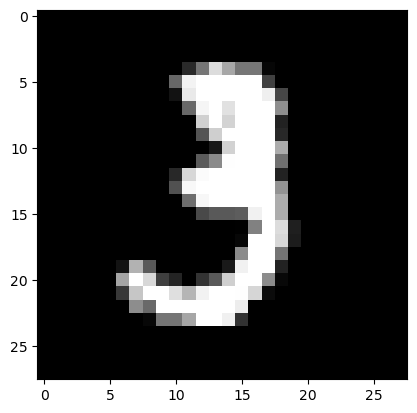

In [5]:
plt.imshow(x_train[10],cmap="grey")

In [6]:
y_train.shape
y_train[10]

np.uint8(3)

# preprocesing

In [7]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [8]:
x_train[0].reshape(28*28,).shape
x_train.reshape(60000,28*28)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [9]:
x_train_reshaped= x_train.reshape(60000,28*28)
x_train_reshaped.shape

(60000, 784)

In [10]:
x_test_reshaped = x_test.reshape(10000,28*28)
x_test_reshaped.shape

(10000, 784)

In [11]:
x_train_scaled =x_train_reshaped/255
x_test_scaled=x_test_reshaped/255

In [12]:
## 2. scale your data standardscaler and normalization
x_train_reshaped[0]/255

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [13]:
print(x_train_scaled.shape,y_train.shape)
print(x_test_scaled.shape,y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


Model Architecture Design

In [14]:
model = keras.Sequential([
    keras.layers.Dense(units=512,activation="relu",name="h_1",input_shape=(784,)),
    keras.layers.Dense(units=256,activation="relu",name="h_2"),
    keras.layers.Dense(units=10,activation="softmax",name="output")
])

c:\Users\mvand\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h_1 (Dense)                     │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h_2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
loaded_model= keras.models.load_model('model/digit.h5')

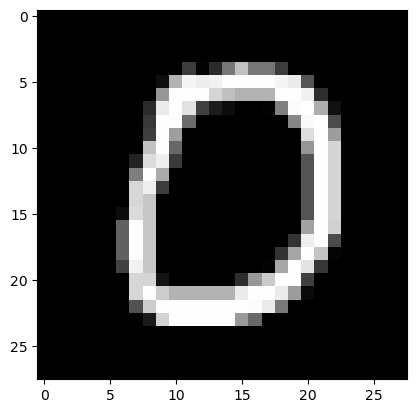

In [32]:
plt.imshow(x_test[10],cmap="grey")

In [30]:
y_test[10]

np.uint8(0)

In [33]:
test_reshaped=x_test[10].reshape(784,)
test_scaled=test_reshaped/255
test_scaled.shape


(784,)

In [35]:
np.argmax(loaded_model.predict(test_scaled.reshape(1,784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


np.int64(0)

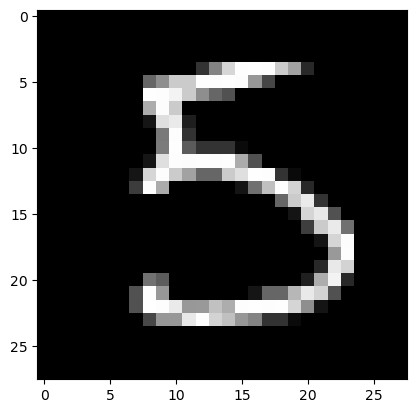

In [37]:
plt.imshow(x_test[15],cmap="grey")

In [40]:
y_test[15]

np.uint8(5)

In [41]:
test_reshaped=x_test[15].reshape(784,)
test_scaled=test_reshaped/255
test_scaled.shape

(784,)

### Define compilation

In [16]:
model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    #metrics = ["f1_score"]
    metrics=["accuracy"]


)

callback

In [17]:
stopping_criteria=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=0,
    mode="auto",
    restore_best_weights=True
)

### Pass data for trainig

In [18]:
model.fit(x_train_scaled,y_train,epochs=100,validation_data=(x_test_scaled,y_test), callbacks = [stopping_criteria])

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9436 - loss: 0.1873 - val_accuracy: 0.9665 - val_loss: 0.1060
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9752 - loss: 0.0799 - val_accuracy: 0.9781 - val_loss: 0.0721
Epoch 3/100
1098/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9841 - loss: 0.0507

KeyboardInterrupt: 

In [77]:
model.fit(x=x_train_scaled,y=y_train,
          epochs=100,
          validation_data=(x_test_scaled,y_test),
          batch_size=64,
          callbacks = [stopping_criteria]
          )

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9630 - loss: 0.1182 - val_accuracy: 0.9678 - val_loss: 0.0986
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9791 - loss: 0.0653 - val_accuracy: 0.9758 - val_loss: 0.0764
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9850 - loss: 0.0460 - val_accuracy: 0.9795 - val_loss: 0.0674
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9883 - loss: 0.0364 - val_accuracy: 0.9816 - val_loss: 0.0604
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9913 - loss: 0.0265 - val_accuracy: 0.9786 - val_loss: 0.0780
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9921 - loss: 0.0235 - val_accuracy: 0.9780 - val_loss: 0.0876
Epoch 7/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9930 - loss: 0.0208 - val_accuracy: 0.9805 - val_loss: 0.0803
Epoch 8/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9948 - loss: 0.0165 - val_accu

In [19]:
model.layers


[<Dense name=h_1, built=True>,
 <Dense name=h_2, built=True>,
 <Dense name=output, built=True>]

In [20]:
model.layers[0].get_weights()[0]

array([[ 0.06788841, -0.02661995, -0.04932025, ...,  0.02093125,
        -0.04076284,  0.05941916],
       [ 0.06134261,  0.02732087,  0.0300412 , ..., -0.06446017,
        -0.03769442,  0.00127815],
       [-0.05205374,  0.05979609, -0.01362934, ...,  0.01442344,
        -0.05809164,  0.01065496],
       ...,
       [-0.06383607,  0.05501355, -0.03250418, ..., -0.03841047,
        -0.03636561,  0.00085574],
       [-0.06516763, -0.015868  ,  0.02056218, ...,  0.05625293,
        -0.03013695, -0.02002976],
       [ 0.00569579, -0.04529735, -0.00665127, ...,  0.00794829,
        -0.04200148, -0.0258424 ]], dtype=float32)

In [21]:
model.layers[0].get_weights()[1]

array([-7.37670460e-04, -4.17194888e-02,  7.42029166e-03,  4.48741065e-03,
       -2.45673396e-02,  5.18773161e-02, -4.35614362e-02, -4.25088173e-03,
       -5.07919304e-02,  3.17121260e-02, -4.61893342e-03, -2.71887351e-02,
        6.74679922e-03, -1.13529451e-02, -2.48352941e-02,  2.04190128e-02,
       -5.29593192e-02,  1.75707806e-02, -3.20719182e-02, -1.75985228e-02,
       -1.82135217e-02, -3.16481665e-02, -1.03788916e-02,  2.96559650e-03,
        1.56942231e-03,  3.09138629e-03, -4.44472209e-02,  2.00264119e-02,
       -5.11060543e-02,  5.90795055e-02,  4.52227704e-02, -7.85963493e-04,
       -6.58508688e-02, -2.85933390e-02,  1.68071818e-02, -8.30155984e-03,
       -3.49563509e-02, -1.76328458e-02, -3.66451405e-02, -3.04685696e-03,
        4.64700116e-03, -2.56444495e-02,  2.25465302e-03,  3.72962020e-02,
        7.58835580e-04, -3.19070406e-02,  1.46104640e-03,  8.78302753e-03,
       -1.25922551e-02,  1.14635546e-02,  3.36549431e-02, -1.07624661e-02,
       -3.74656939e-03,  

In [22]:
model.layers[2].get_weights()[1]

array([-0.0385154 , -0.05445223, -0.01887259, -0.02693241,  0.01235561,
       -0.0069596 , -0.04966801, -0.06659255,  0.14872022,  0.02206962],
      dtype=float32)

Save model

In [25]:
model.save('model/digit.h5') 

Design SVM 

In [24]:
loaded_model= keras.models.load_models(model/digit.h5)

AttributeError: module 'keras.models' has no attribute 'load_models'

checking shape for error

In [29]:
x_train_scaled.shape


(60000, 784)

In [30]:
y_train.shape

(60000,)

In [31]:
y_test.shape

(10000,)

In [32]:
x_test_scaled.shape

(10000, 784)

In [51]:
import tensorflow_addons as tfa
print(tfa.__version__)

ModuleNotFoundError: No module named 'tensorflow_addons'

Callback 